In [5]:
from google.colab import files
uploaded = files.upload()

Saving enriched_social_media_dataset.csv to enriched_social_media_dataset.csv


In [6]:
df = pd.read_csv(
    "enriched_social_media_dataset.csv"
)

In [7]:
df.shape

(705, 30)

In [8]:
features = [
    'Age',
    'Avg_Daily_Usage_Hours',
    'Sleep_Hours_Per_Night',
    'Mental_Health_Score',
    'Conflicts_Over_Social_Media',
    'App_Switch_Frequency',
    'Notification_Response_Time',
    'Relapse_Frequency',
    'Short_Form_Content_Ratio',
    'Attention_Recovery_Time',
    'Late_Night_Usage_Index',
    'Usage_Escalation_Rate',
    'Session_Binge_Score'
]

In [9]:
y = df['Brain_Rot_Index']

In [10]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df['Brain_Rot_Index']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
!pip install xgboost -q

In [12]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [13]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = mean_squared_error(y_test, preds) ** 0.5
r2 = r2_score(y_test, preds)

print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))
print("R2:", round(r2,3))

MAE: 0.77
RMSE: 1.03
R2: 0.995


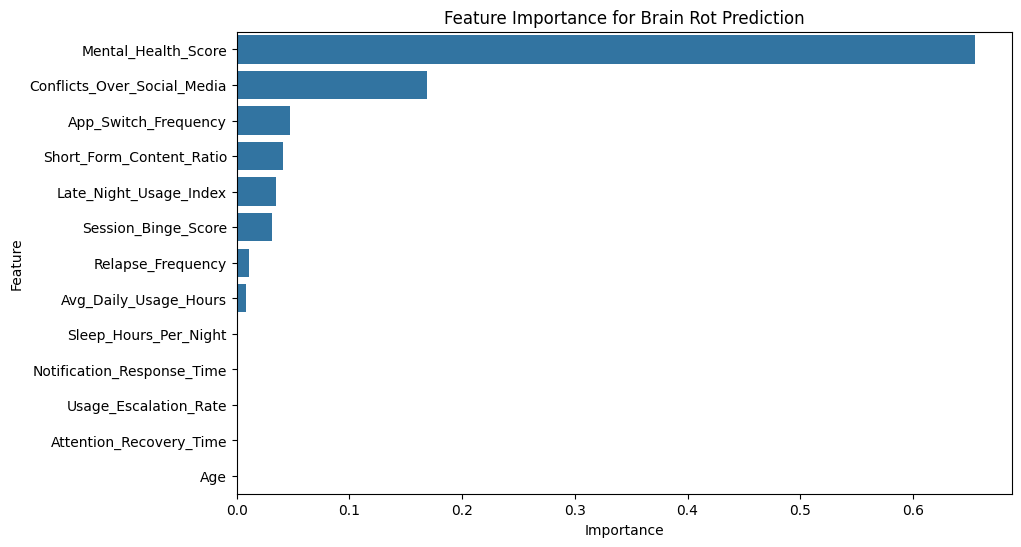

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

importance = pd.DataFrame({
    'Feature': features,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    "Feature Importance for Brain Rot Prediction"
)

plt.show()

In [16]:
!pip install shap -q

In [17]:
import shap

In [18]:
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

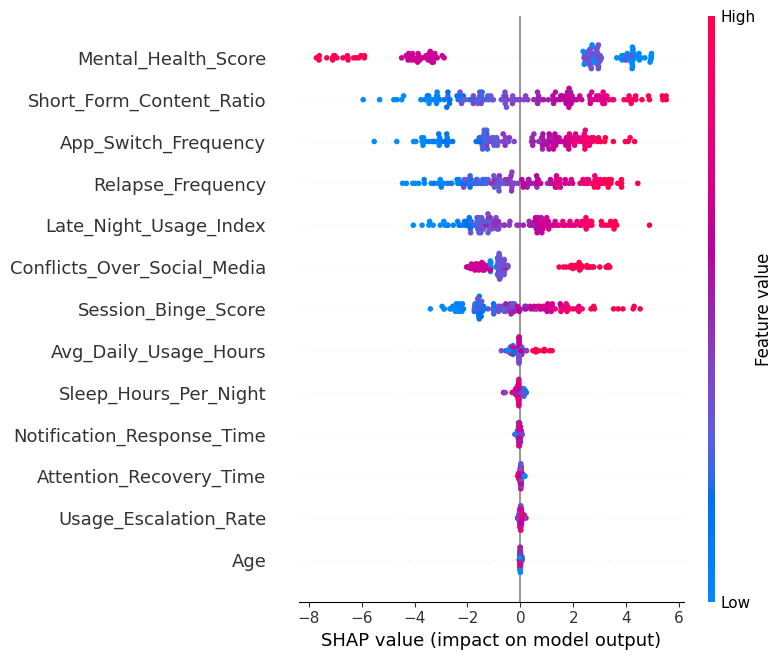

In [19]:
shap.summary_plot(
    shap_values,
    X_test
)